# Imports

In [36]:
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import umap

from sklearn.cluster import KMeans
from transformers import AutoProcessor, SiglipVisionModel
from ultralytics import YOLO

base_path = os.path.join("..", "..")

# Configuracoes
VIDEO_PATH = os.path.join(base_path, "videos/Maniacos_Dynamite/Posse_Dynamite.mp4") # Coloque o caminho do seu video aqui
DETECTOR_WEIGHTS = os.path.join(base_path, "models/detector/yolo26m-basketball.pt")
SEG_WEIGHTS = os.path.join(base_path, "models/seg/yolo26m-seg.pt")
PLAYER_CLASS_IDS = {3, 4, 5, 6, 7} # Seus IDs de jogadores detectados anteriormente

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[*] Usando dispositivo: {device}")

# Carregando Modelos
print("[*] Carregando YOLO Detector...")
detector = YOLO(DETECTOR_WEIGHTS)

print("[*] Carregando YOLO Segmenter...")
segmenter = YOLO(SEG_WEIGHTS)

print("[*] Carregando SigLIP Vision Backbone...")
processor = AutoProcessor.from_pretrained("google/siglip-base-patch16-224")
siglip_model = SiglipVisionModel.from_pretrained("google/siglip-base-patch16-224").to(device)
siglip_model.eval()

print("[*] Setup concluido.")

[*] Usando dispositivo: cuda
[*] Carregando YOLO Detector...
[*] Carregando YOLO Segmenter...
[*] Carregando SigLIP Vision Backbone...


Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 8097.11it/s]


[*] Setup concluido.


# Data Mining

In [37]:
# %% [Cell 2]
print("[*] Minerando crops dourados do video...")
cap = cv2.VideoCapture(VIDEO_PATH)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

golden_crops = []
target_crops = 100

for progress in np.arange(0.1, 0.9, 0.05): # Pula o inicio/fim, amostra ao longo do video
    if len(golden_crops) >= target_crops:
        break
        
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(total_frames * progress))
    ret, frame = cap.read()
    if not ret: continue
        
    det_results = detector.predict(frame, conf=0.7, verbose=False)[0]
    seg_results = segmenter.predict(frame, conf=0.4, verbose=False)[0]
    
    if det_results.boxes is None or seg_results.masks is None: continue
        
    det_boxes = det_results.boxes.xyxy.cpu().numpy()
    det_classes = det_results.boxes.cls.cpu().numpy()
    
    seg_masks = seg_results.masks.xy
    
    for box, cls_id in zip(det_boxes, det_classes):
        if int(cls_id) not in PLAYER_CLASS_IDS: continue
            
        x1, y1, x2, y2 = map(int, box)
        w, h = x2 - x1, y2 - y1
        if w < 20 or h < 50: continue # Ignora muito pequenos
            
        # Acha a melhor mascara
        best_mask = None
        best_score = 0
        box_area = w * h
        
        for poly in seg_masks:
            if len(poly) < 3: continue
            
            # Simple bounding box of the polygon for fast overlap check
            px1, py1 = np.min(poly, axis=0)
            px2, py2 = np.max(poly, axis=0)
            
            inter_w = max(0, min(x2, px2) - max(x1, px1))
            inter_h = max(0, min(y2, py2) - max(y1, py1))
            overlap = (inter_w * inter_h) / box_area
            
            if overlap > best_score:
                best_score = overlap
                # Rasterize mask
                mask_img = np.zeros(frame.shape[:2], dtype=np.uint8)
                cv2.fillPoly(mask_img, [np.round(poly).astype(np.int32)], 1)
                best_mask = mask_img
                
        if best_mask is not None and best_score > 0.4:
            crop = frame[y1:y2, x1:x2].copy()
            mask_crop = best_mask[y1:y2, x1:x2]
            crop[mask_crop == 0] = [0, 0, 0] # Fundo preto
            golden_crops.append(crop)

cap.release()
print(f"[*] Coletados {len(golden_crops)} crops dourados.")

[*] Minerando crops dourados do video...
[*] Coletados 105 crops dourados.


# Reality Check

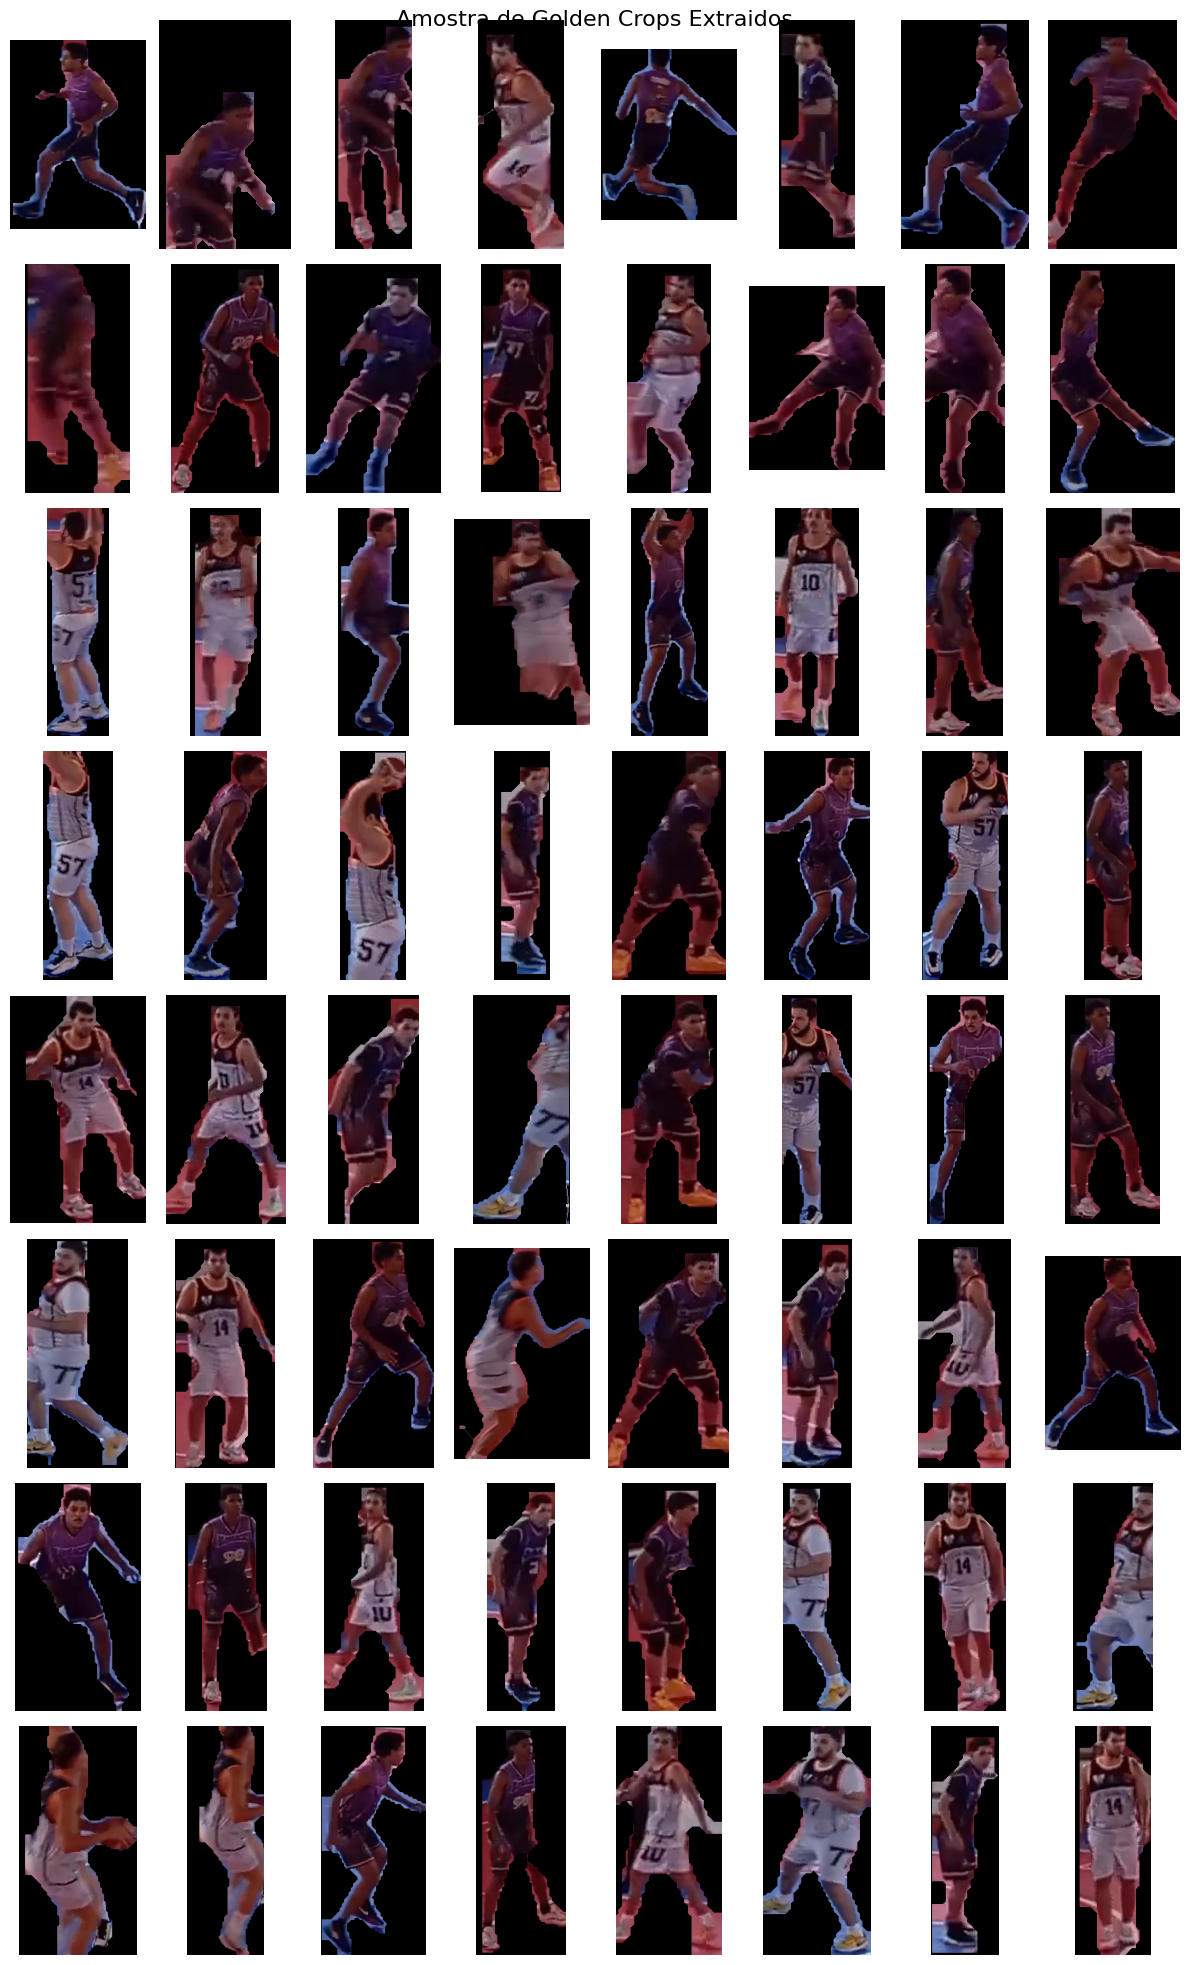

In [38]:
# %% [Cell 3]
def plot_crop_grid(crops, title, num_items=64):
    n = min(len(crops), num_items)
    cols = 8
    rows = int(np.ceil(n / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols*1.5, rows*2.5))
    fig.suptitle(title, fontsize=16)
    
    for i, ax in enumerate(axes.flatten()):
        if i < n:
            rgb_crop = cv2.cvtColor(crops[i], cv2.COLOR_BGR2RGB)
            ax.imshow(rgb_crop)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Observe essa imagem com atencao: Os jogadores estao bem isolados?
plot_crop_grid(golden_crops, "Amostra de Golden Crops Extraidos")

# SigLip Debug

[*] Extraindo embeddings SigLIP...
[*] Reduzindo dimensao com UMAP e clusterizando...


/home/victor/miniconda3/envs/tail/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


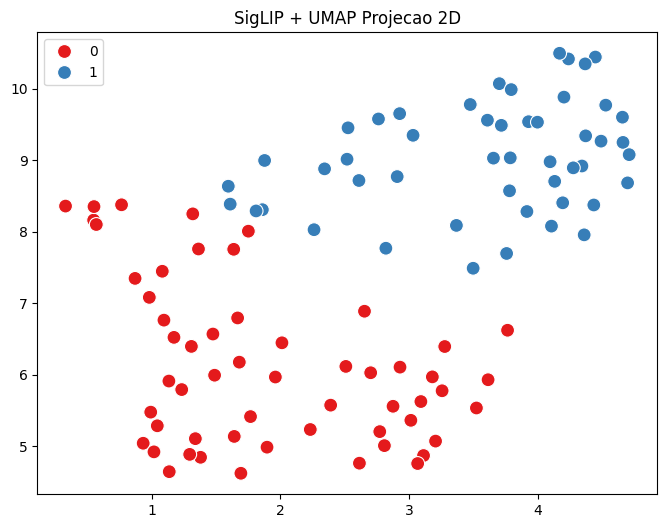

In [39]:
# %% [Cell 4]
print("[*] Extraindo embeddings SigLIP...")
siglip_embeddings = []

with torch.inference_mode():
    for crop in golden_crops:
        rgb_crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        inputs = processor(images=rgb_crop, return_tensors="pt").to(device)
        outputs = siglip_model(**inputs)
        
        # O segredo: media dos patches visuais
        features = torch.mean(outputs.last_hidden_state, dim=1)
        features = torch.nn.functional.normalize(features, dim=-1)
        siglip_embeddings.append(features.cpu().numpy()[0])

siglip_embeddings = np.array(siglip_embeddings)

print("[*] Reduzindo dimensao com UMAP e clusterizando...")
reducer_siglip = umap.UMAP(n_components=2, metric='cosine', random_state=42)
proj_siglip = reducer_siglip.fit_transform(siglip_embeddings)

kmeans_siglip = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_siglip = kmeans_siglip.fit_predict(proj_siglip)

# Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=proj_siglip[:, 0], y=proj_siglip[:, 1], hue=labels_siglip, palette="Set1", s=100)
plt.title("SigLIP + UMAP Projecao 2D")
plt.show()

# SigLip Accountability Check

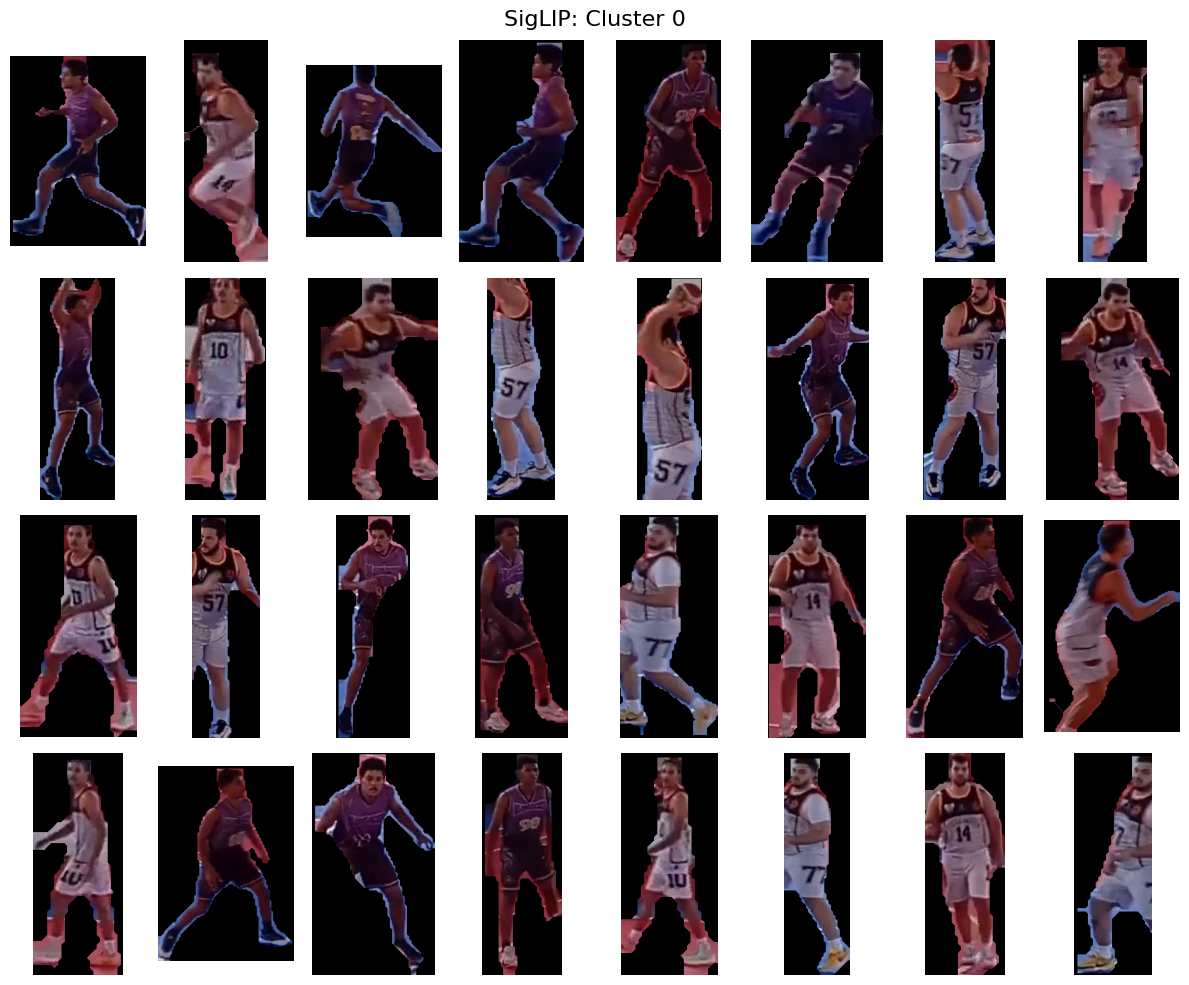

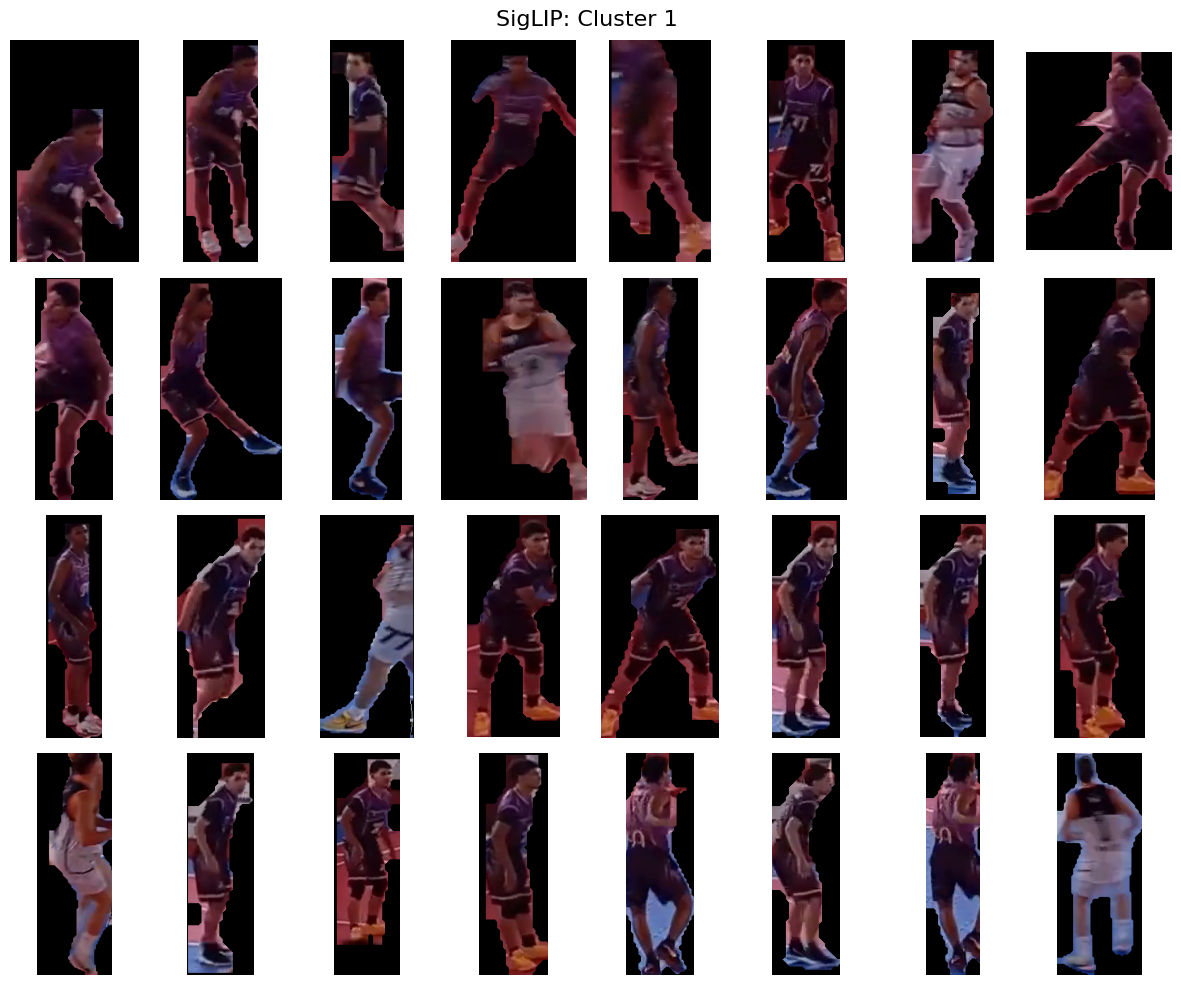

In [40]:
# %% [Cell 5]
siglip_cluster_0 = [golden_crops[i] for i in range(len(golden_crops)) if labels_siglip[i] == 0]
siglip_cluster_1 = [golden_crops[i] for i in range(len(golden_crops)) if labels_siglip[i] == 1]

plot_crop_grid(siglip_cluster_0, "SigLIP: Cluster 0", num_items=32)
plot_crop_grid(siglip_cluster_1, "SigLIP: Cluster 1", num_items=32)

# HSV Debugging

[*] Extraindo Histogramas HSV...
[*] Reduzindo dimensao com UMAP e clusterizando...


/home/victor/miniconda3/envs/tail/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


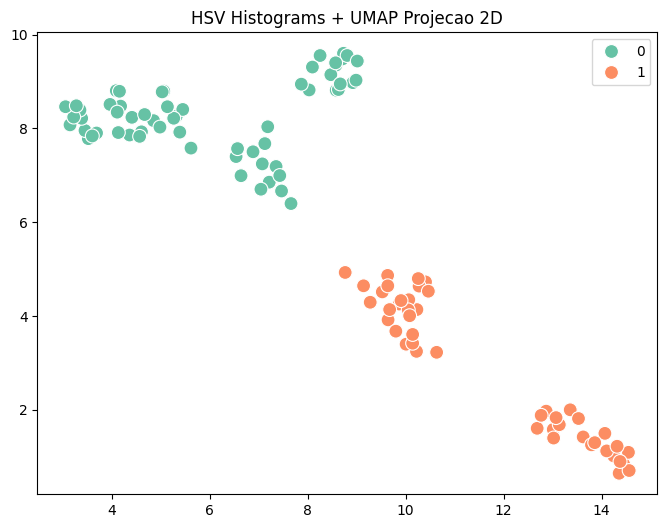

In [41]:
# %% [Cell 6]
print("[*] Extraindo Histogramas HSV...")
hsv_features = []

for crop in golden_crops:
    mask = np.any(crop > 0, axis=-1).astype(np.uint8) * 255
    hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
    
    # Canal 0 (Matiz/Cor) e Canal 1 (Saturacao). Ignora brilho.
    hist = cv2.calcHist([hsv], [0, 1], mask, [32, 16], [0, 180, 0, 256])
    cv2.normalize(hist, hist, alpha=1.0, norm_type=cv2.NORM_L2)
    hsv_features.append(hist.flatten())

hsv_features = np.array(hsv_features)

print("[*] Reduzindo dimensao com UMAP e clusterizando...")
reducer_hsv = umap.UMAP(n_components=2, metric='cosine', random_state=42)
proj_hsv = reducer_hsv.fit_transform(hsv_features)

kmeans_hsv = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_hsv = kmeans_hsv.fit_predict(proj_hsv)

# Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=proj_hsv[:, 0], y=proj_hsv[:, 1], hue=labels_hsv, palette="Set2", s=100)
plt.title("HSV Histograms + UMAP Projecao 2D")
plt.show()

# HSV Accountability Check

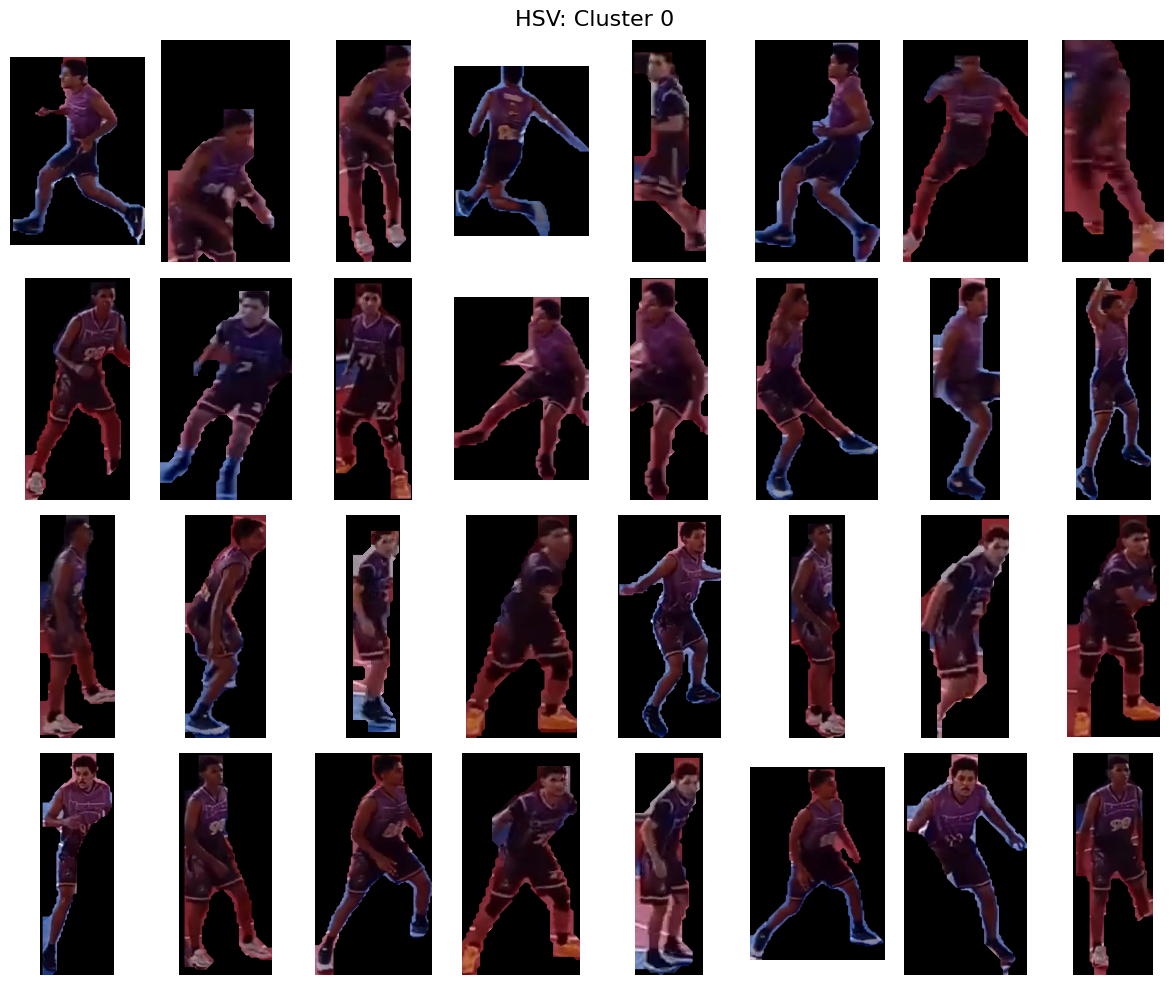

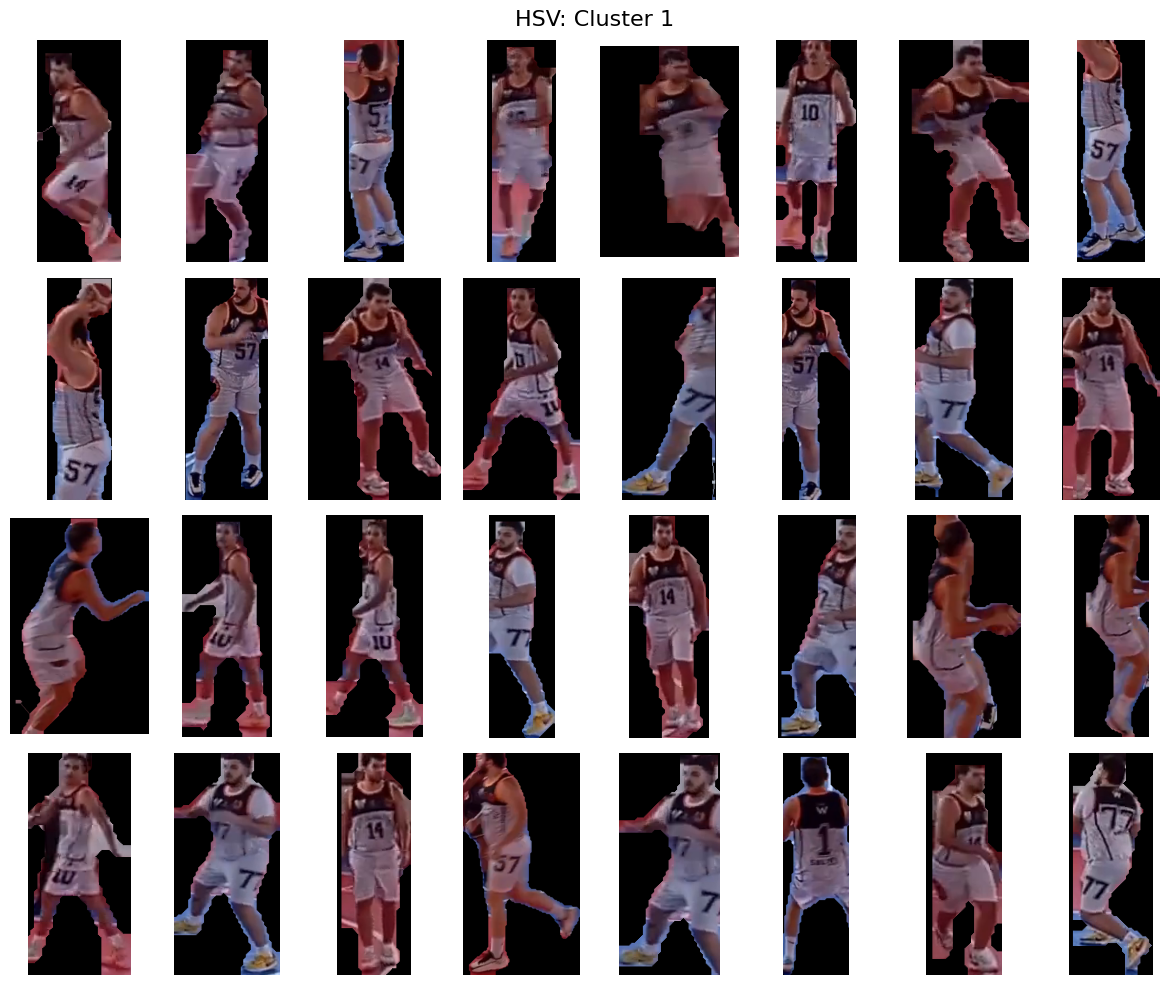

In [42]:
# %% [Cell 7]
hsv_cluster_0 = [golden_crops[i] for i in range(len(golden_crops)) if labels_hsv[i] == 0]
hsv_cluster_1 = [golden_crops[i] for i in range(len(golden_crops)) if labels_hsv[i] == 1]

plot_crop_grid(hsv_cluster_0, "HSV: Cluster 0", num_items=32)
plot_crop_grid(hsv_cluster_1, "HSV: Cluster 1", num_items=32)

In [43]:
contador = 5

[*] Executando pipeline completo no frame 6...
[*] Extraindo embeddings para 9 jogadores...


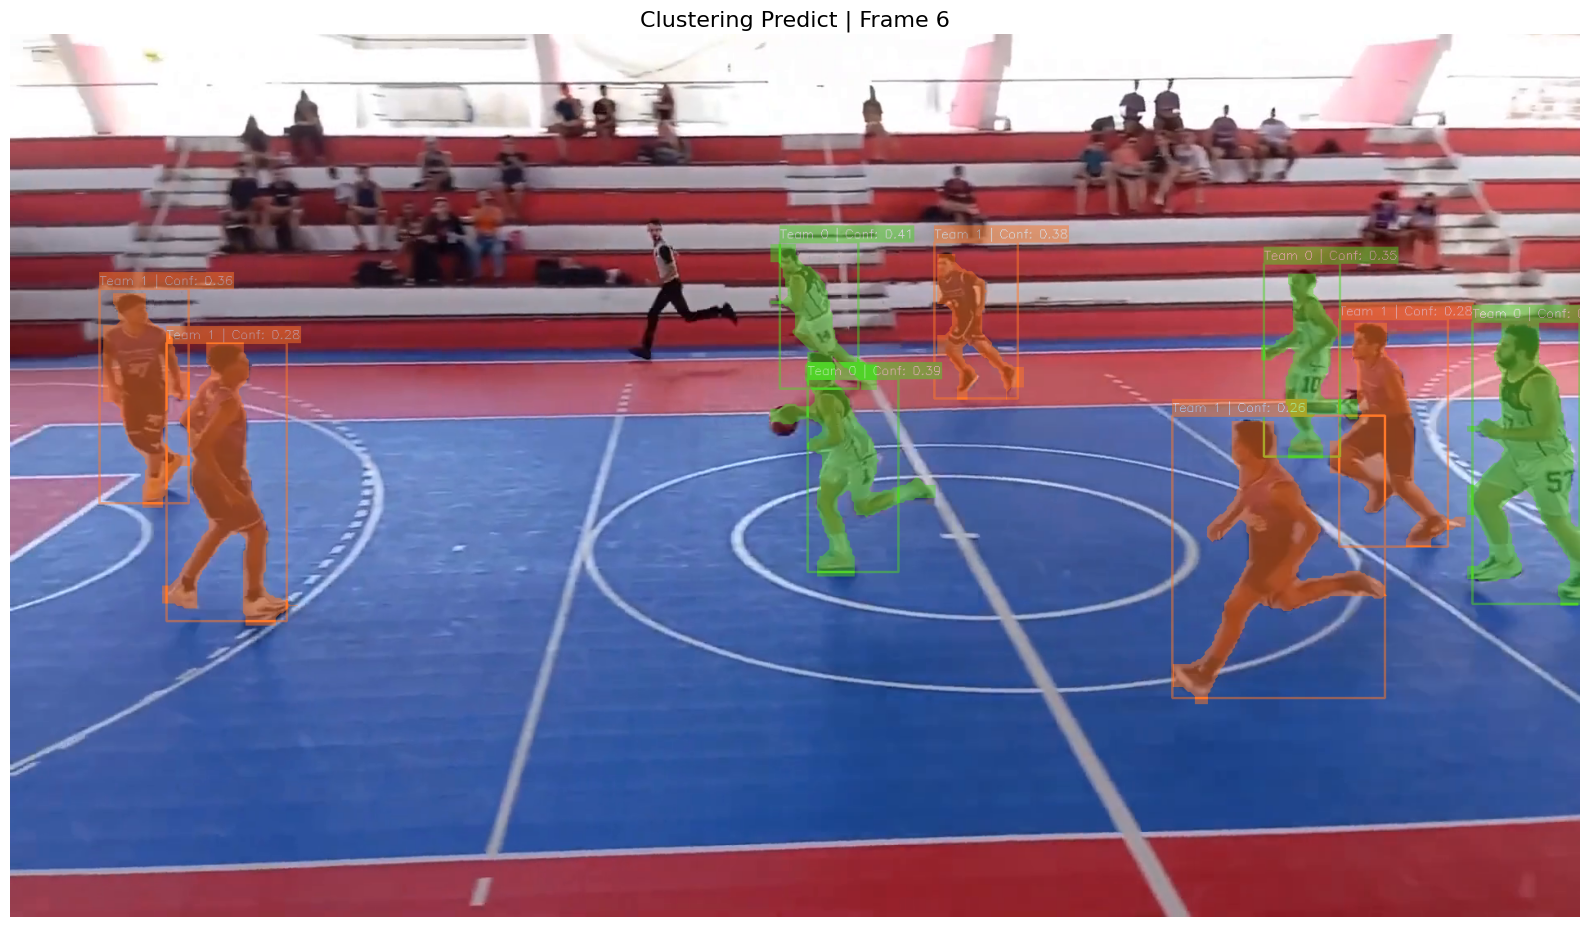

In [44]:
# %% [Cell 9] Inspecao Visual Completa (Deteccao + Segmentacao + Clustering)
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt


contador += 1

# Garante que os modelos da Fase 1 foram treinados
if 'reducer_siglip' not in locals() or 'kmeans_siglip' not in locals():
    print("[!] Erro: Rode a Celula 4 primeiro para treinar o UMAP e o KMeans.")
else:
    # --- CONFIGURACOES ---
    cap = cv2.VideoCapture(VIDEO_PATH)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    FRAME_NUMBER = int(contador) # Escolha o frame aqui
    
    cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_NUMBER)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print(f"[!] Erro ao ler o frame {FRAME_NUMBER}.")
    else:
        print(f"[*] Executando pipeline completo no frame {FRAME_NUMBER}...")
        
        display_frame = frame.copy()
        overlay = display_frame.copy()
        alpha = 0.5  # Transparencia da mascara
        
        # 1. Visao: Deteccao e Segmentacao
        det_results = detector.predict(frame, conf=0.45, verbose=False)[0]
        seg_results = segmenter.predict(frame, conf=0.25, verbose=False)[0]
        
        valid_crops = []
        valid_boxes = []
        valid_masks = []
        
        if det_results.boxes is not None and seg_results.masks is not None:
            det_boxes = det_results.boxes.xyxy.cpu().numpy()
            det_classes = det_results.boxes.cls.cpu().numpy()
            seg_masks = seg_results.masks.xy
            
            for box, cls_id in zip(det_boxes, det_classes):
                if int(cls_id) not in PLAYER_CLASS_IDS: continue
                    
                x1, y1, x2, y2 = map(int, box)
                w, h = x2 - x1, y2 - y1
                if w < 20 or h < 50: continue
                    
                best_mask = None
                best_score = 0
                box_area = w * h
                
                for poly in seg_masks:
                    if len(poly) < 3: continue
                    px1, py1 = np.min(poly, axis=0)
                    px2, py2 = np.max(poly, axis=0)
                    
                    inter_w = max(0, min(x2, px2) - max(x1, px1))
                    inter_h = max(0, min(y2, py2) - max(y1, py1))
                    overlap = (inter_w * inter_h) / box_area
                    
                    if overlap > best_score:
                        best_score = overlap
                        mask_img = np.zeros(frame.shape[:2], dtype=np.uint8)
                        cv2.fillPoly(mask_img, [np.round(poly).astype(np.int32)], 1)
                        best_mask = mask_img
                
                if best_mask is not None and best_score > 0.4:
                    crop = frame[y1:y2, x1:x2].copy()
                    mask_crop = best_mask[y1:y2, x1:x2]
                    crop[mask_crop == 0] = [0, 0, 0] # Fundo preto
                    
                    valid_crops.append(crop)
                    valid_boxes.append((x1, y1, x2, y2))
                    valid_masks.append(best_mask)
        
        # 2. Cerebro: Extracao de Embeddings e Clustering
        if len(valid_crops) > 0:
            print(f"[*] Extraindo embeddings para {len(valid_crops)} jogadores...")
            frame_embeddings = []
            
            with torch.inference_mode():
                # Processa em lote para velocidade
                rgb_crops = [cv2.cvtColor(c, cv2.COLOR_BGR2RGB) for c in valid_crops]
                inputs = processor(images=rgb_crops, return_tensors="pt", padding=True).to(device)
                outputs = siglip_model(**inputs)
                
                features = torch.mean(outputs.last_hidden_state, dim=1)
                features = torch.nn.functional.normalize(features, dim=-1)
                frame_embeddings = features.cpu().numpy()
            
            # Projeta no UMAP e preve no KMeans treinados na Celula 4
            proj_embeddings = reducer_siglip.transform(frame_embeddings)
            distances = kmeans_siglip.transform(proj_embeddings)
            predictions = np.argmin(distances, axis=1)
            confidences = 1.0 / (1.0 + np.min(distances, axis=1))
            
            # 3. Pincel: Desenhando os Times
            TEAM_COLORS = {
                0: (40, 210, 80),  # Verde (Padrão BGR do OpenCV)
                1: (40, 120, 255)  # Vermelho/Laranja
            }
            
            for i in range(len(valid_crops)):
                x1, y1, x2, y2 = valid_boxes[i]
                mask = valid_masks[i]
                team_id = predictions[i]
                conf = confidences[i]
                
                color = TEAM_COLORS.get(team_id, (128, 128, 128))
                
                # Mascara
                overlay[mask == 1] = color
                # Bounding Box
                cv2.rectangle(display_frame, (x1, y1), (x2, y2), color, 2)
                
                # Label com fundo
                label = f"Team {team_id} | Conf: {conf:.2f}"
                (text_w, text_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
                cv2.rectangle(display_frame, (x1, y1 - 20), (x1 + text_w, y1), color, -1)
                cv2.putText(display_frame, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
            
            # Mescla para criar transparencia
            cv2.addWeighted(overlay, alpha, display_frame, 1 - alpha, 0, display_frame)
            
            # Exibe
            plt.figure(figsize=(16, 10))
            plt.imshow(cv2.cvtColor(display_frame, cv2.COLOR_BGR2RGB))
            plt.title(f"Clustering Predict | Frame {FRAME_NUMBER}", fontsize=16)
            plt.axis('off')
            plt.tight_layout()
            plt.show()
        else:
            print("[!] Nenhum crop valido encontrado neste frame para clusterizar.")